In [2]:

#%pip install --upgrade git+https://github.com/rwightman/pytorch-image-models.git

In [3]:

import random 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.metrics import ConfusionMatrixDisplay

import torch 
import torch.nn as nn 
import torch.optim as optim 
from torch.nn import functional as F 

import torchvision as vision 
import torchvision.transforms as transform 
from timm.layers import DropPath,to_2tuple, trunc_normal_

In [4]:

# setting the seed for reproducibility:
#for python:
random.seed(42)

#for pytorch:
g = torch.Generator().manual_seed(42)


In [5]:
r""" 
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Add this line
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_set, val_set = torch.utils.data.random_split(train_dataset, [40000, 10000])
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
"""
# seeting up the device:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)


cpu



<br>

# `#01: Patch Partition:`

<br>


### `FLOPs:`

### **What is FLOPs and why it's important?**
FLOPs(Floating Point Operations Per Second)  হলো একটি মডেলের কম্পিউটেশনাল জটিলতা পরিমাপের একটি একক। এটি নির্দেশ করে যে একটি নিউরাল নেটওয়ার্কের অপারেশন (যেমন, গুণ, যোগ) সম্পাদন করতে কতগুলো ফ্লোটিং-পয়েন্ট অপারেশন প্রয়োজন। FLOPs গণনা করা গুরুত্বপূর্ণ কারণ এটি:
1. **মডেলের দক্ষতা পরিমাপ**: কম FLOPs মানে মডেলটি কম কম্পিউটেশনাল রিসোর্স ব্যবহার করে, যা দ্রুত ইনফারেন্স এবং কম শক্তি খরচের জন্য উপকারী।
2. **হার্ডওয়্যারের সাথে তুলনা**: মোবাইল বা এমবেডেড ডিভাইসে মডেল চালানোর জন্য FLOPs গণনা করে হার্ডওয়্যারের সক্ষমতার সাথে মেলানো যায়।
3. **মডেল অপটিমাইজেশন**: বড় মডেলের জন্য FLOPs কমিয়ে মডেলকে হালকা করা যায়, যা প্রশিক্ষণ এবং ইনফারেন্সে সময় বাঁচায়।

---



### `#01 Input Format এবং Channel Dimension-এর অবস্থান:`

##### 1. PyTorch-input tensor:
- **নরমাল ইমেজ রিডিং**: যখন আপনি একটি সাধারণ ইমেজ (যেমন PNG বা JPG) PyTorch-এর `PIL` (Python Imaging Library) বা `OpenCV` দিয়ে রিড করেন, তখন ইমেজটি সাধারণত `[height, width, channels]` ফরম্যাটে থাকে। উদাহরণস্বরূপ:
  - একটি RGB ইমেজের জন্য: `[224, 224, 3]`।
- **PyTorch-এর প্রত্যাশা**: তবে, PyTorch-এর নিউরাল নেটওয়ার্ক (যেমন `nn.Module`) এবং ডেটালোডারগুলো (যেমন `DataLoader`) ইনপুট টেনসরকে `[batch_size, channels, height, width]` ফরম্যাটে প্রত্যাশা করে। উদাহরণস্বরূপ:
  - একটি ব্যাচে 4টি ইমেজ হলে: `[4, 3, 224, 224]`।
- **কারণ**: PyTorch-এর কনভলিউশনাল লেয়ার (যেমন `nn.Conv2d`) এবং অন্যান্য অপারেশনগুলো চ্যানেল ডাইমেনশনকে প্রথমে রাখতে পছন্দ করে, কারণ এটি GPU-এর প্যারালাল প্রসেসিং-এর জন্য অপ্টিমাইজড।

##### 2. Channel Dimension-এর আগে নেওয়ার লাভ কী?
- **কার্যকারিতা**: PyTorch-এ চ্যানেল ডাইমেনশন (C) প্রথমে রাখা হয়, কারণ:
  - **কনভলিউশন অপারেশন**: `nn.Conv2d` লেয়ার চ্যানেলগুলোকে প্রথমে প্রসেস করে (ইনপুট চ্যানেল → ফিল্টার অ্যাপ্লাই → আউটপুট চ্যানেল), যা GPU-এ প্যারালালাইজেশনের জন্য অপ্টিমাইজড।
  - **ফিচার এক্সট্রাকশন**: চ্যানেল (RGB বা অন্যান্য ফিচার) মডেলের প্রথম স্তরে গুরুত্বপূর্ণ, তাই এটি শুরুতে থাকলে প্রসেসিং দ্রুত হয়।
- **লাভ**:
  - **স্থিতিশীলতা**: ইনপুটের চ্যানেল সংখ্যা (C) স্থির থাকলে, মডেলের সারা স্তরে এটি সামঞ্জস্য রাখে।
  - **স্কেলেবিলিটি**: ব্যাচ সাইজ (B) পরিবর্তনযোগ্য হওয়ায়, এটি শেষে রাখা হয়, যা ব্যাচ প্রসেসিং-এ সুবিধাজনক।
  - **পারফরম্যান্স**: GPU-এর মেমোরি অ্যাক্সেস প্যাটার্নের সাথে এই ফরম্যাট মানানসই।
- **দৃষ্টান্ত**: যদি `[height, width, channels]` ফরম্যাটে থাকে, তবে প্রতিটি চ্যানেলের জন্য আলাদা প্রসেসিং করতে হবে, যা কম দক্ষ। `[channels, height, width]` ফরম্যাটে সব চ্যানেল একসাথে প্রসেস হয়।

---

In [6]:

class PatchPartition(nn.Module):
    r""" Image to Patch Embedding
    Args:
        img_size (int): Image size.  Default: 224.
        patch_size (int): Patch token size. Default: 4.
        in_img_chanel (int): Number of input image channels. Default: 3.
        out_img_chanel (int): Number of linear projection output channels. Default: 96.
        norm_layer (nn.Module, optional): Normalization layer. Default: None
    """
    def __init__(self,img_size,patch_size,in_img_chanel,out_img_chanel,layer_norm:None):
        super().__init__()
        img_size = to_2tuple(img_size) #224,224
        patch_size = to_2tuple(patch_size)#4,4
        #(224/4,224/4)=(56,56)
        patch_resolution = img_size[0]//patch_size[0],img_size[1]//patch_size[1]
        
        
        self.img_size = img_size
        self.patch_size = patch_size
        self.patch_resolution = patch_resolution
        self.num_patches = patch_resolution[0] * patch_resolution[1] #56*56=3136
        
        self.in_img_chanel = in_img_chanel
        self.out_img_chanel = out_img_chanel
        
        # linear embedding part:
        self.proj = nn.Conv2d(in_channels=in_img_chanel,out_channels=out_img_chanel,
                              kernel_size=patch_size,stride=patch_size)
        
        if layer_norm is not None:
            self.layer_norm = layer_norm(out_img_chanel)
        else:
            self.layer_norm = None
        
    def forward(self,X):
        B,C,H,W = X.shape #batch,channel,height,width,[1,3,244,244]
        assert H==self.img_size[0] and W==self.img_size[1],f"""Input image size 
        ({H},{W}) does not match model expect ({self.img_size[0]},{self.img_size[1]})"""
        
        x = self.proj(X) #1,96,56,56
        x = torch.flatten(input=x,start_dim=2) # 1,96,(56*56) = 1,96,3136
        x = x.transpose(1,2) # 1,3136,96
        return x 
    
    def flops(self):
        # conv2D: param's + output
        ph,pw = self.patch_resolution 
        flops = (self.in_img_chanel * self.out_img_chanel * self.patch_size[0] 
                 * self.patch_size[1] * ph * pw)
        
        # layer normalization
        if self.layer_norm is not None:
            # output elemnts
            flops += self.out_img_chanel * ph * pw 
        return flops 
    


In [7]:

# test the function:
from PIL import Image
x = Image.open("../02_vision_transformer/image/images.jpg")
x = x.resize((224,224))
x = np.array(x)
x = torch.from_numpy(x).float()
x = x[None,...]
x = x.permute(0,3,1,2)
print(x.shape)

torch.Size([1, 3, 224, 224])


In [8]:

pp = PatchPartition(img_size=224,
                    patch_size=4,
                    in_img_chanel=3,
                    out_img_chanel=96,
                    layer_norm=nn.LayerNorm)
out = pp(x)
out.shape 

torch.Size([1, 3136, 96])

In [9]:
# calculate in Million: 1M = 100k
flops = pp.flops() / 1000000
print(f"flops: {flops} Million")

flops: 14.751744 Million


In [10]:
# 14.75 multi adds:
from torchinfo import summary
summary(model=pp,input_size=(1,3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
PatchPartition                           [1, 3136, 96]             192
├─Conv2d: 1-1                            [1, 96, 56, 56]           4,704
Total params: 4,896
Trainable params: 4,896
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 14.75
Input size (MB): 0.60
Forward/backward pass size (MB): 2.41
Params size (MB): 0.02
Estimated Total Size (MB): 3.03

<br>
<br>

# `#02 Patch Merging:`

<br>


`Patch Partition এর মধ্যে আমরা, image কে patch এ convert করেছি (outdim: [1,3136,96]) । এরপর একে swin transformer block এ পাঠাবো(outdim: [1,3136,96]), এর পর patch merging এ পাঠাবো (outdim: [1,784,192])।`

<br>

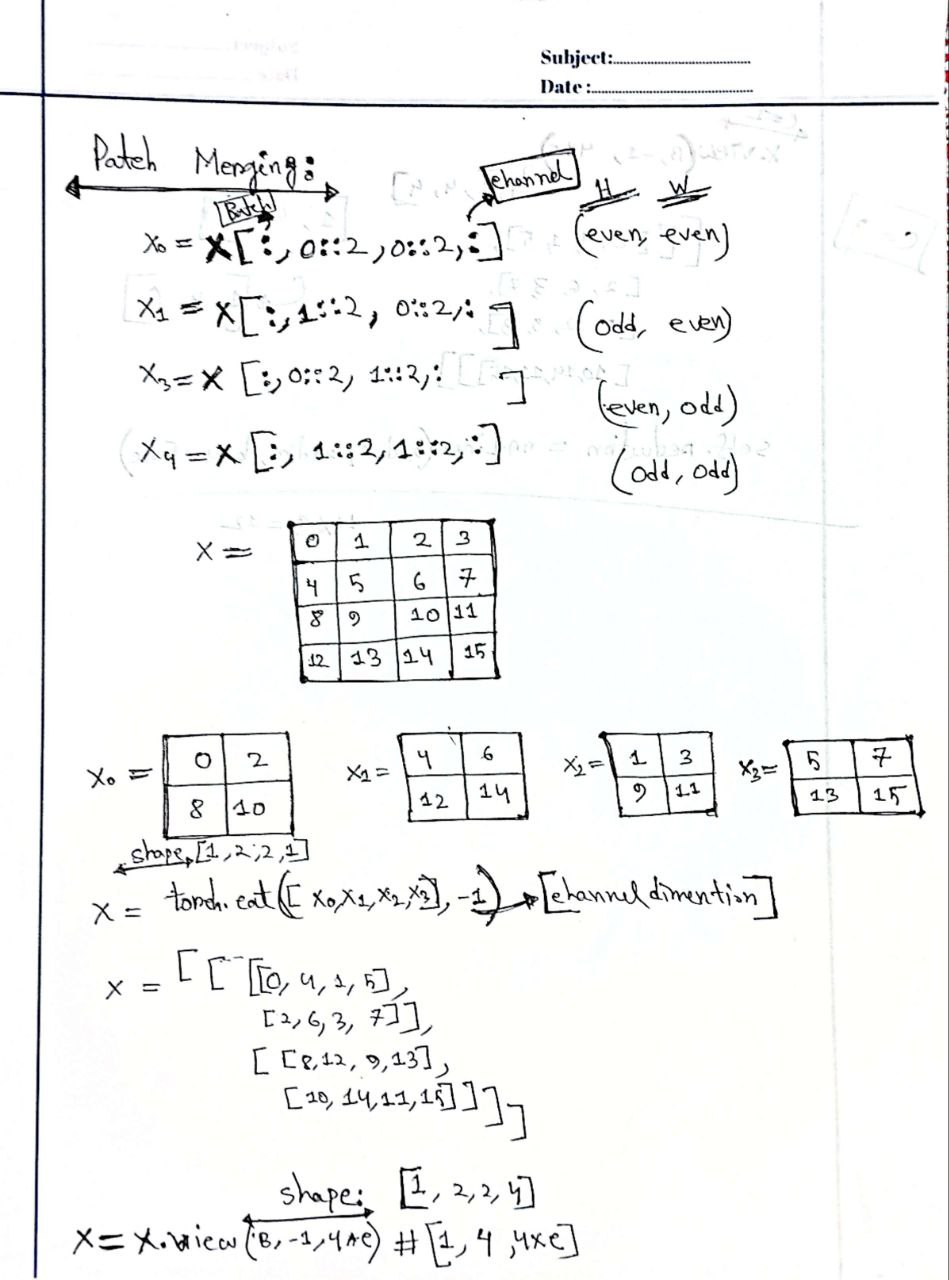

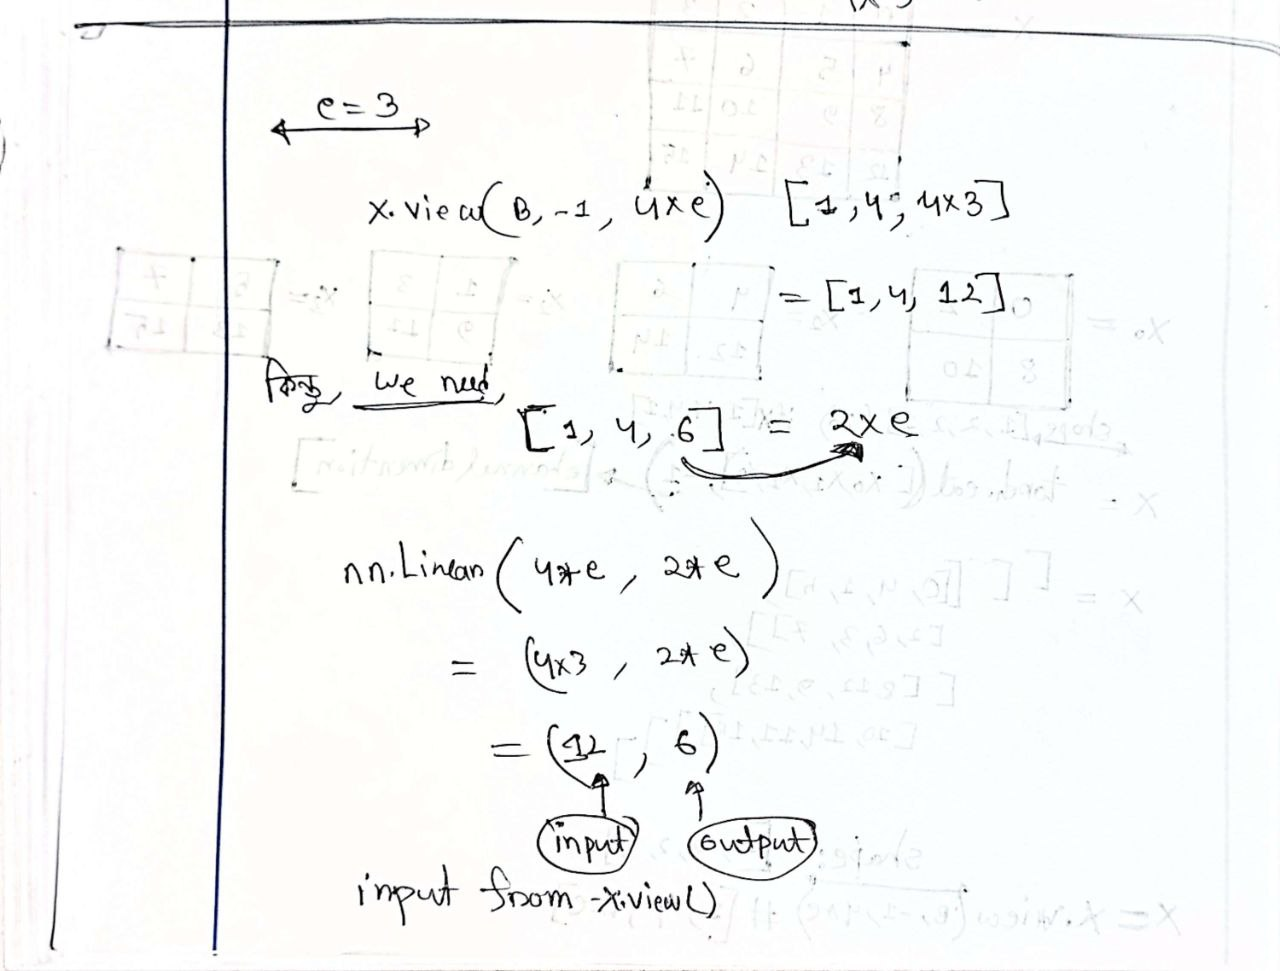

In [11]:
from IPython.display import display,Image 
display(Image(data="img/img15.jpg"))
display(Image(data="img/img16.jpg"))

In [12]:


class PatchMerging(nn.Module):
    r""" Patch Merging Layer.
    Args:
        input_resolution (tuple[int]): Resolution of input feature.
        dim (int): Number of input channels.
        norm_layer (nn.Module, optional): Normalization layer.  Default: nn.LayerNorm
    """
    def __init__(self,input_resolution,dim,layer_norm:nn.LayerNorm):
        super().__init__()
        self.input_resolution = input_resolution
        self.dim = dim 
        self.reduction = nn.Linear(in_features=4*dim,
                                            out_features=2*dim,bias=False)
        self.layer_norm = layer_norm(4 * dim)
        
    def forward(self,x):
        H,W = self.input_resolution
        # B, H*W , C = [1, 56*56, 96]
        B,L,C = x.shape 
        
        assert L==H*W,"Input feature wrong: PachMerging"
        assert H%2==0 and W%2==0,f"size: ({H},{W}) are not even."
        
        x = x.view(B,H,W,C) #[1,56,56,96]
        
        x0 = x[:,0::2,0::2,:] # H:even W:even [1,28,28,96] skip: one value:
        x1 = x[:,1::2,0::2,:] # H:odd W:even  [1,28,28,96]
        x2 = x[:,0::2,1::2,:] # H:even W:odd  [1,28,28,96]
        x3 = x[:,1::2,1::2,:] # H:odd W:odd   [1,28,28,96]
        
        # concatinate in channel dimention:
        x = torch.concat(tensors=[x0,x1,x2,x3],dim=-1) #[1,28,28,4*96]
        x = x.view(1,-1,4*C)
        
        x = self.layer_norm(x)
        
        #reduction into: 2C,
        """ 
        Research are very smart, they just not use average them up to ruduce the channel 
        dimention. Just we do in pooling. They think and made it a learnable parameter.Why, 
        they do this, becuase research want to touch the dataset to make any preprocessing.
        """
        x = self.reduction(x)
        return x 
    
    
        


In [13]:

# test the patchmerging:
print(out.shape)
pm = PatchMerging(input_resolution=(56,56),
                  dim=96,
                  layer_norm=nn.LayerNorm)
out = pm(out)
print(out.shape)


torch.Size([1, 3136, 96])
torch.Size([1, 784, 192])


In [14]:
summary(model=pm,input_size=(1,3136,96))

Layer (type:depth-idx)                   Output Shape              Param #
PatchMerging                             [1, 784, 192]             --
├─LayerNorm: 1-1                         [1, 784, 384]             768
├─Linear: 1-2                            [1, 784, 192]             73,728
Total params: 74,496
Trainable params: 74,496
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.07
Input size (MB): 1.20
Forward/backward pass size (MB): 3.61
Params size (MB): 0.30
Estimated Total Size (MB): 5.11

<br>
<br>

# `#03 Swin Transformer Block:`

<br>

`WindowAttention ক্লাসটি Swin Transformer-এর একটি মূল অংশ, যা Window-based Multi-Head Self-Attention (W-MSA) এবং Shifted Window-based Multi-Head Self-Attention (SW-MSA) বাস্তবায়ন করে।`

**But in research paper, W-MSA and SW-MSA  দুইটা ভিন্ন layer এ প্রয়োগ করা হয়েছে , কিন্তু, আমরা এই দুইটা এখানে একই class এ দুইটা প্রয়োগ করবো । যদি mask apply করি তাহলে এইটা SW-MSA এর মতো কাজ করবে, আর যদি mask apply না করি তাহলে W-MSA এর মতো কাজ করবে ।**

<br>

#### **প্যারামিটার গুলো কীভাবে কাজে লাগবে?**
1. **`dim, window_size, num_heads, qkv_bias, attn_drop, proj_drop`:**
   - `dim`: ইনপুট চ্যানেল সংখ্যা।
   - `window_size (Wh, Ww)`: উইন্ডোর উচ্চতা ও প্রস্থ।
   - `num_heads`: অ্যাটেনশন হেডের সংখ্যা।
   - `qkv_bias, attn_drop, proj_drop`: কোয়েরি, কী, ভ্যালু লিনিয়ার লেয়ার ও ড্রপআউটের কনফিগারেশন।
   - **কাজ:** QKV (কোয়েরি, কী, ভ্যালু) তৈরি ও অ্যাটেনশন স্কোর ক্যালকুলেশনের জন্য।

2. **`self.scale`:**
   - `head_dim ** -0.5`: Q এবং K-এর ডট প্রোডাক্ট স্কেল করতে।
   - **কাজ:** অ্যাটেনশন স্কোর স্থিতিশীল রাখে।

3. **`self.qkv, self.linearTransform, self.softmax`:**
   - `qkv`: QKV তৈরি করে।
   - `linearTransform`: আউটপুট প্রজেক্ট করে।
   - `softmax`: অ্যাটেনশন ওয়েট নরমালাইজ করে।
   - **কাজ:** মাল্টি-হেড অ্যাটেনশন মেকানিজম চালায়।

4. **`relative_position_bias_table`:**
   - আকার: `(2*Wh-1) * (2*Ww-1, num_heads)`।
   - `trunc_normal_(..., std=0.02)`: শিখনযোগ্য বায়াস ইনিশিয়ালাইজ করে।
        ```python
        attn = (q @ k.transpose(-2, -1)) * self.scale + self.relative_position_bias_table    [relative_pos_index]
        attn = self.softmax(attn)
        ```
   - **কাজ:** টোকেন জোড়ার সাপেক্ষ অবস্থানের জন্য বায়াস যোগ করে অ্যাটেনশন উন্নত করে।

5. **`coords, coords_flatten, relative_coords`:**
   - `coords`: উইন্ডোর x, y স্থানাঙ্ক তৈরি করে।
   - `relative_coords`: টোকেন জোড়ার dx, dy পার্থক্য গণনা করে।
   - **কাজ:** সাপেক্ষ পার্থক্য বের করে।

6. **`relative_coords[:,:,0] += Wh-1, += Ww-1`:**
   - নেতিবাচক মান 0-তে সরায়।
   - **কাজ:** সূচক তৈরির জন্য প্রস্তুতি।

7. **`relative_coords[:,:,0] *= 2 * Ww - 1`:**
   - dx-কে স্কেল করে dx + dy-এর জন্য অনন্য মান নিশ্চিত করে।
   - **কাজ:** সূচকের ভিন্নতা বজায় রাখে।

8. **`relative_pos_index = relative_coords.sum(-1)`:**
   - dx + dy থেকে একটি সূচক তৈরি করে।
   - **কাজ:** প্রতিটি জোড়ার সাপেক্ষ অবস্থান নির্দেশ করে।

9. **`self.register_buffer("relative_pos_index", relative_pos_index)`:**
   - সূচকটি স্থায়ীভাবে সংরক্ষণ করে।
   - **কাজ:** পুনরায় গণনা এড়ায়, দক্ষতা বাড়ায়।


In [15]:

def window_partition(x,window_size):
    r""" 
        Args:
            x:(B,H,W,C)
            windows_size : int
        return:
            windows(number_of_windows*B,window_size,window_size,C)
    """
    B,H,W,C = x.shape # 1,28,28,192
    x = x.view(B,H//window_size,window_size,W//window_size,window_size,C)#1,28/ws,ws,28/ws,ws,192
    x = x.permute(0,1,3,2,4,5)#1,28/ws,28/ws,ws,ws,192 => (28/ws) * (28/ws) = total_num_window
    x = x.contiguous().view(-1,window_size,window_size,C) #(batch_size*total_num_window),ws,ws,192
    return x
    

def window_reverse(window,window_size,H,W):
    """
    Args:
        windows: (num_windows*B, window_size, window_size, C)
        window_size (int): Window size
        H (int): Height of image
        W (int): Width of image

    Returns:
        x: (B, H, W, C)
    """
    B = window_size.shape(0) // ((H//window_size)*(W//window_size))
    window = window.view(B,H//window_size,W//window_size,window_size,window_size,-1) 
    x = x.permute(0,1,3,2,4,5)
    x = x.contiguous().view(B,H,W,-1) 
    return x #B,H,W,C


In [16]:

# <----------------------Slice in python------------------->
my_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
s = slice(2, 5)  # start=2, stop=5
result = my_list[s]
print(result)  # [2, 3, 4]


[2, 3, 4]


In [17]:

# W-MSA: No need of mask.
# SW-MSA: We need mask. Below mask is for SW-MSA
# <------------Creating a attention mask based on shifted window---------------------->
window_size = 4
shift_size = window_size//2
H = 16
W = 16 
img_mask = torch.zeros(size=(1,H,W,1)) #1,16,16,1

""" 
Slice the image grid into 3*3 = 9 Block
"""
h_slice = (
           slice(0,-window_size),
           slice(-window_size,-shift_size),
           slice(-shift_size,None)
           )

w_slice = (
           slice(0,-window_size),
           slice(-window_size,-shift_size),
           slice(-shift_size,None)
           )

cnt = 0
for h in h_slice:
    for w in w_slice:
        img_mask[:,h,w,:] = cnt 
        cnt +=1
print(f"Image Mask Shape: {img_mask.shape}")


# img_mask: (4x4)->Window
mask_window = window_partition(img_mask,window_size)
# 16,4,4,1
# In, total we have 16 windows,windows size: [4,4,1]
print(f"Masked Windows Shape: {mask_window.shape}")


# flatten the Window:
""" 
[[0, 0, 0, 0, ..., 0],  # window: 0
 [1, 1, 1, 1, ..., 1],  # window: 1
 [2, 2, 2, 2, ..., 2],  # window: 2
 ...
 [15, 15, 15, 15, ..., 15]]16x16 #Window: 15
"""
mask_window = mask_window.view(-1,window_size*window_size)
# (16,16)
print(f"Masked Window Shape After View: {mask_window.shape}")

# unsqueeze(1)-->(16,16)-->(16,1,16)
""" 
[[[0, 0, 0, 0, ..., 0]],  # window: 0
 [[1, 1, 1, 1, ..., 1]],  # window: 1
 [[2, 2, 2, 2, ..., 2]],  # window: 2
 ...
 [[15, 15, 15, 15, ..., 15]]]16x1x16 #Window: 15
"""
# unsqueeze(2)-->(16,16)-->(16,16,1)
""" 
[[[0], [0], [0], [0], [0]],    # Window: 0
 [[1], [1], [1], [1], [1]],    # Window: 1
 [[2], [2], [2], [2], [2]],    # Window: 2
 ...
 [[15], [15], [15], [15], [15]]]  # Window: 15
"""
# To Perfrom Subtranction. PyTorch automatically change shape, Called: Broadcating. 
# (16, 1, 16) and  (16, 16, 1) to (16, 16, 16)
# **Result of subtranction:**
""" 
attn_mask[i, j, k] = mask_window[i, k] - mask_window[j, k]
i হলো প্রথম উইন্ডোর ইনডেক্স (0 থেকে 15),
j হলো দ্বিতীয় উইন্ডোর ইনডেক্স (0 থেকে 15),
k হলো টোকেনের ইনডেক্স (0 থেকে 15, কারণ প্রতি উইন্ডোর 16 টোকেন)।

Take only three to understand:
**Masked_window:**
[[0, 0],  # উইন্ডো 0
 [1, 1],  # উইন্ডো 1
 [2, 2]]  # উইন্ডো 2

**Unsqueeze(1)**
[[[0, 0]],
 [[1, 1]],
 [[2, 2]]]
 
**Unsqueeze(2)**
[[[0], [0]],
 [[1], [1]],
 [[2], [2]]]
 
**Subtraction:**
attn_mask[i, j, k] = mask_window[i, k] - mask_window[j, k]
(i=0, j=0): [0, 0] - [0, 0] = [0, 0] (উইন্ডো 0 - উইন্ডো 0),
(i=0, j=1): [0, 0] - [1, 1] = [-1, -1] (উইন্ডো 0 - উইন্ডো 1),
(i=0, j=2): [0, 0] - [2, 2] = [-2, -2] (উইন্ডো 0 - উইন্ডো 2),
(i=1, j=0): [1, 1] - [0, 0] = [1, 1] (উইন্ডো 1 - উইন্ডো 0),
(i=1, j=1): [1, 1] - [1, 1] = [0, 0] (উইন্ডো 1 - উইন্ডো 1),
(i=1, j=2): [1, 1] - [2, 2] = [-1, -1] (উইন্ডো 1 - উইন্ডো 2),
(i=2, j=0): [2, 2] - [0, 0] = [2, 2] (উইন্ডো 2 - উইন্ডো 0),
(i=2, j=1): [2, 2] - [1, 1] = [1, 1] (উইন্ডো 2 - উইন্ডো 1),
(i=2, j=2): [2, 2] - [2, 2] = [0, 0] (উইন্ডো 2 - উইন্ডো 2)
Result:
[[[0, 0], [-1, -1], [-2, -2]],
 [[1, 1], [0, 0], [-1, -1]],
 [[2, 2], [1, 1], [0, 0]]]
 
"""
attn_mask = mask_window.unsqueeze(1) - mask_window.unsqueeze(2)
print(f"Attention Maked Shape: {attn_mask.shape}")

# atten_mask!=0, (different window token)
# atten_mask==0, (same token in same window)
""" 
Why 0 and -100:
This mask will use to calculate attention:
যখন আমরা mask apply করি না । তখন, normal attention প্রয়োগ হয় ।
তখন, একই window তে থাকা patch গুলোর মধ্যে attention  calculate করি । 
কিন্তু, যখন, sw-msa এর জন্য আমাদের masking apply করা লাগে, sw-msa প্রইয়োগ করার আগে 
আমরা cyclic shift  করি । করার পর, আমরা যে mask  এর code এ -১০০ বা  0 apply করি ।
এইটা দিয়ে আসলে কি বুঝায়? এইক windows এ থাকা দুইটা patch যারা cyclic shift করার আগে আলাদা আলাদা 
window তে ছিল তাদের attention calculate করা । 

softmax(-100) = 0,
- ফলে, যেখানে -100.0 আছে, সেখানে অ্যাটেনশন ওয়েট প্রায় 0 হয়ে যায়।
- Attention weight zero means: আমরা চাই না যে ভিন্ন উইন্ডোর টোকেনগুলো (যেমন উইন্ডো 0 এবং উইন্ডো 1) একে 
অপরের সাথে অ্যাটেনশন করুক।

softmax(0) = 1
- একই উইন্ডোর টোকেনগুলো (যেমন উইন্ডো 0-এর সব টোকেন) একে অপরের সাথে অ্যাটেনশন করতে পারে।
 
"""
attn_mask = attn_mask.masked_fill(attn_mask!=0,float(-100.0)).masked_fill(attn_mask==0,float(0.0))
print(f"attn_mask shape after masked_fill: {attn_mask.shape}")



Image Mask Shape: torch.Size([1, 16, 16, 1])
Masked Windows Shape: torch.Size([16, 4, 4, 1])
Masked Window Shape After View: torch.Size([16, 16])
Attention Maked Shape: torch.Size([16, 16, 16])
attn_mask shape after masked_fill: torch.Size([16, 16, 16])


In [18]:

print(mask_window.unsqueeze(1).shape)
print(mask_window.unsqueeze(2).shape)


torch.Size([16, 1, 16])
torch.Size([16, 16, 1])


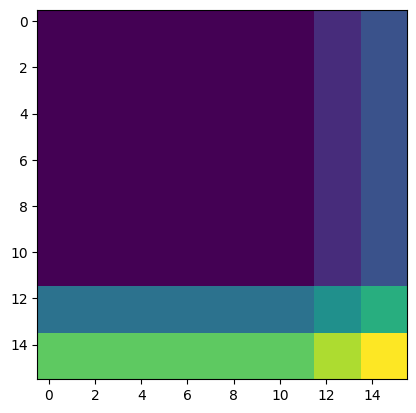

In [19]:

plt.imshow(img_mask.squeeze(0).squeeze(-1).detach().numpy())
plt.colormaps()
plt.show()


## **(MSA বা SW-MSA) গণনা করে। এটি নিম্নলিখিত উপাদানগুলো নিয়ে গঠিত হবে:**

- **Initialization- (__init__):**
    **প্যারামিটার:** ইনপুট চ্যানেল (dim), উইন্ডো সাইজ (window_size), অ্যাটেনশন হেডের সংখ্যা (num_heads), কুয়েরি/কী/ভ্যালু বায়াস (qkv_bias), অ্যাটেনশন ড্রপআউট (attn_drop), প্রজেকশন ড্রপআউট (proj_drop)।

    **লিনিয়ার লেয়ার:** কুয়েরি, কী, এবং ভ্যালু (qkv) তৈরির জন্য একটি লিনিয়ার লেয়ার এবং আউটপুট প্রজেকশনের জন্য আরেকটি লিনিয়ার লেয়ার।

    **রিলেটিভ পজিশন বায়াস:** উইন্ডোর মধ্যে টোকেনের সাপেক্ষিক অবস্থানের জন্য বায়াস টেবিল।

    **ড্রপআউট:** অ্যাটেনশন ওয়েট এবং আউটপুটের জন্য ড্রপআউট।

    **সফটম্যাক্স:** অ্যাটেনশন স্কোর নরমালাইজ করার জন্য।

- **Why we need Relative position bias:**
    রিলেটিভ পজিশন বায়াস হলো Swin Transformer-এর WindowAttention মডিউলের একটি গুরুত্বপূর্ণ অংশ, যা টোকেন জোড়ার (পিক্সেল বা প্যাচ) সাপেক্ষিক স্থানিক অবস্থানের উপর ভিত্তি করে অ্যাটেনশন স্কোরে একটি লার্নেবল বায়াস যোগ করে।

    `Standard ViT তে আমরা learnable positional embedding বের করেছিলাম, যার ফলে আমদের কোন patch এর পর কোন patch আসবে তা মডেল খুব ভালোভাবে শিখতে পারে, এখানে, একই windows এর মধ্যে করা আশে পাশে কোন patch থাকবে এর জন্য learable bias তৈরি করতে হয়.`

    **রিলেটিভ পজিশন বায়াস একটি লার্নেবল প্যারামিটার (relative_position_bias_table) যা ট্রেনিংয়ের সময় অপটিমাইজ করা হয়। এটি প্রতিটি টোকেন জোড়ার সাপেক্ষিক দূরত্বের(relative distance) উপর ভিত্তি করে অ্যাটেনশন স্কোরে একটি বায়াস যোগ করে, যা মডেলকে স্থানিক তথ্য আরও ভালোভাবে শিখতে সাহায্য করে।**

- **How to calculate Relative Distance:**
    
    - **কোঅর্ডিনেট তৈরি:(()) coords_h এবং coords_w উইন্ডোর মধ্যে টোকেনের x এবং y স্থানাঙ্ক তৈরি করে।
    - **ফ্ল্যাটেন:** স্থানাঙ্কগুলোকে একটি 1D অ্যারেতে রূপান্তর করা হয়।
    - **সাপেক্ষিক দূরত্ব:** প্রতিটি টোকেন জোড়ার জন্য dx (x-দূরত্ব) এবং dy (y-দূরত্ব) গণনা করা হয়।
    - **নন-নেগেটিভ শিফট:** dx এবং dy কে নন-নেগেটিভ করার জন্য উইন্ডো সাইজের সাথে যোগ করা হয়।
    - **ইনডেক্স গণনা:** dx এবং dy যোগ করে একটি ইউনিক ইনডেক্স তৈরি করা হয়, যা relative_position_bias_table থেকে বায়াস নির্বাচনের জন্য ব্যবহৃত হয়।

- কেন এই পদ্ধতি?:
    `এটি সব সম্ভাব্য সাপেক্ষিক দূরত্বের (dx, dy) জন্য একটি ইউনিক ইনডেক্স তৈরি করে, যা বায়াস টেবিল থেকে সঠিক বায়াস নির্বাচন করতে সাহায্য করে।`

- **Example:**
    ধরুন, একটি 4×4 উইন্ডোর মধ্যে টোকেনগুলোর স্থানাঙ্ক হলো: (0,0), (0,1), (1,0), (1,1)। <br>
    **সাপেক্ষিক দূরত্ব:**
    - টোকেন (0,0) এবং (1,1) এর মধ্যে dx = 1-0 = 1, dy = 1-0 = 1।
    - টোকেন (0,1) এবং (1,0) এর মধ্যে dx = 1-0 = 1, dy = 0-1 = -1।

    **বায়াস টেবিল:**
    - (2*4-1)=7 তাই, dx এবং dy এর রেঞ্জ হলো [-3, 3]।
    - টেবিলের আকার: (2*4-1)*(2*4-1)=49।
    - প্রতিটি (dx, dy) জোড়ার জন্য একটি ইউনিক বায়াস মান থাকে, যা অ্যাটেনশন স্কোরে যোগ হয়।


In [20]:


class WindowAttention(nn.Module):
    r""" Window based multi-head self attention (W-MSA) module with relative position bias.
     It supports both of shifted and non-shifted window.

     Args:
        dim (int): Number of input channels.
        window_size (tuple[int]): The height and width of the window.
        num_heads (int): Number of attention heads.
        qkv_bias (bool, optional):  If True, add a learnable bias to query, key, value. Default: True
        qk_scale (float | None, optional): Override default qk scale of head_dim ** -0.5 if set
        attn_drop (float, optional): Dropout ratio of attention weight. Default: 0.0
        proj_drop (float, optional): Dropout ratio of output. Default: 0.0
    """
    def __init__(self,dim,window_size,num_heads,qkv_bias=True,attn_drop=0,proj_drop=0):
        super().__init__()
        self.dim = dim 
        self.window_size = window_size # Wh,Ww
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        # Avoids floating-point recomputation errors
        self.scale = (self.head_dim)**(-0.5)
        self.qkv = nn.Linear(in_features=dim,out_features=3*dim,bias=qkv_bias) # c,3c
        self.linearTrnasfortn = nn.Linear(in_features=dim,out_features=dim) # c,c 
        self.softmax = F.softmax(dim=-1)
        self.attn_drop = attn_drop
        self.proj_drop = proj_drop
        
        """ 
        **Relative_Position_Bias_Table**
        relative position bias, which adds a learnable bias to the attention scores 
        based on the relative positions of token pairs within a window.
        """
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2*window_size[0]-1) * (2*window_size[1]-1),self.num_heads))
        coords_h = torch.arange(self.window_size[0]) #[0,1,2,3] if window_size(4,4)
        coords_w = torch.arange(self.window_size[1]) #[0,1,2,3]
        """ 
        coords এর আকার (2, Wh, Ww) হয়, যেখানে প্রথম সারি (index 0)
        x-স্থানাঙ্ক (width) এবং দ্বিতীয় সারি (index 1) y-স্থানাঙ্ক (height) ধরে।
        coords[0] = [[0, 0, 0, 0],
                    [1, 1, 1, 1], 
                    [2, 2, 2, 2], 
                    [3, 3, 3, 3]] (x-স্থানাঙ্ক)।
                    
        coords[1] = [[0, 1, 2, 3],
                     [0, 1, 2, 3], 
                     [0, 1, 2, 3], 
                     [0, 1, 2, 3]] (y-স্থানাঙ্ক)।
        """
        coords = torch.stack(torch.meshgrid([coords_h,coords_w]))
        
        """ 
        [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3], x-axis
        [0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3], y-axis
        """
        #flatten_dim = 2,Wh*Ww
        coords_flatten = torch.flatten(coords,start_dim=1)
        #relative coordinates:(1st dim->x-value, 2nd dim->y-value,None-> add one dim(None))
        #coords_flatten(2,Wh*Ww) --to--> (2,Wh*Ww,1)
        """relative_coords:
        coords_flatten[0] = [0, 0, 1, 1] (x-মান)।
        coords_flatten[1] = [0, 1, 0, 1] (y-মান)।
        relative_coords[0] = [
                             [0-0, 0-0, 0-1, 0-1], 
                             [0-0, 0-0, 0-1, 0-1], 
                             [1-0, 1-0, 1-1, 1-1], 
                             [1-0, 1-0, 1-1, 1-1]] = [[0, 0, -1, -1], [0, 0, -1, -1], 
                             [1, 1, 0, 0], [1, 1, 0, 0]] -> (dx) (x-x)।
                             
        relative_coords[1] = [[0-0, 0-1, 0-0, 0-1], 
                              [1-0, 1-1, 1-0, 1-1], 
                              [0-0, 0-1, 0-0, 0-1], 
                              [1-0, 1-1, 1-0, 1-1]] = [[0, -1, 0, -1], [1, 0, 1, 0], 
                              [0, -1, 0, -1], [1, 0, 1, 0]]-> (dy) (x-x)।
                              
        **relative_coords:* একটি উইন্ডোর মধ্যে টোকেন জোড়ার respect পার্থক্য গণনা করে। 
        যদি ৪টি উইন্ডো থাকে, তবে প্রতিটি উইন্ডোর জন্য আলাদা relative_coords হবে, এবং mask ব্যবহার করে ভিন্ন
        উইন্ডোর টোকেনের মধ্যে অ্যাটেনশন বন্ধ করা হয়। relative_coords গণনা উইন্ডোর মধ্যে টোকেনের স্থানাঙ্কের উপর ভিত্তি করে। যেহেতু প্রতিটি উইন্ডো আলাদা অংশ ধরে (যেমন, উপর-বাম উইন্ডোতে টোকেন (0,0) থেকে (1,1)), তাই প্রতি উইন্ডোর জন্য coords_h এবং coords_w আলাদা হয়।
        **উদাহরণ:** উপর-বাম উইন্ডো (0,0) থেকে (1,1): coords_flatten[0] = [0, 0, 1, 1],
        coords_flatten[1] = [0, 1, 0, 1]।
        নিচ-ডান উইন্ডো (2,2) থেকে (3,3): coords_flatten[0] = [2, 2, 3, 3], 
        coords_flatten[1] = [2, 3, 2, 3]। 
        ###
        প্রতি উইন্ডোর জন্য relative_coords আলাদা হয়, কারণ এটি উইন্ডোর মধ্যে টোকেনের সাপেক্ষ পার্থক্য (dx, dy) 
        নির্ভর করে।
        ###
        ###
        Mask দিয়ে ভিন্ন উইন্ডোর টোকেন জোড়ার অ্যাটেনশন স্কোর -100 করে দেয়, যা softmax-এ 0-এর কাছাকাছি করে, ফলে
        অ্যাটেনশন বন্ধ হয়।
        ###
        """
        # relative_coords: (2,Wh*Ww,1) - (2,1,Wh*ww)
        # (2,Wh*Ww,Wh*Ww)
        relative_coords = coords_flatten[:,:,None] - coords_flatten[:,None,:]
        relative_coords = relative_coords.permute(1,2,0)
        relative_coords = relative_coords.contiguous() #(Wh*Ww,Wh*Ww,2)
        # made -ve value into zero: 
        relative_coords[:,:,0] += self.window_size[0] - 1
        relative_coords[:,:,1] += self.window_size[1] - 1
        
        # with respect to dx and dy: we need to find relative position for each token:
        # so, we can add then up: (dx+dy)
        """ 
        এটি একটি 2x2 উইন্ডোর জন্য, যেখানে 4 টি টোকেন (Wh*Ww = 4) এবং 16টি সম্ভাব্য টোকেন জোড়া আছে। 
        এই token গুলো জন্য আমাদের কাছে x,y coordinate আছে, এখন, আমাদের কাজ হচ্ছে একই  window তে 
        থাকে token গুলোর জন্য একটা relative postion বের করতে হবে । এর জন্য আমরা, dx,dy  কে , যোগ 
        করবো , কিন্ত, dx,xy যেহেতু একই range এর (0,windows_size[0]-1) তো, 
        dx কে wide(windows_size[1]) গুন করে নিব । তারপর, প্রতিটি  
        patch এর corresponding এ একটা ভ্যালু পাবো . 
        """
        relative_coords[:,:,0] *= 2*window_size[1] -1 
        relative_pos_index = relative_coords.sum(dim=-1) #(Wh*Ww,Wh*Ww)
        
        # PyTorch buffer: save this tensor as buffer but not trainbale
        self.register_buffer("relative_pos_index",relative_pos_index)
        
        """
        - relative_position_bias_table-এর মানগুলোকে একটি কাটা নরমাল বিতরণ (truncated normal distribution)
        থেকে ইনিশিয়ালাইজ (initialization) করে। 
        - relative_position_bias_table-এর মানগুলোকে একটি কাটা নরমাল বিতরণ (truncated normal distribution)
        থেকে ইনিশিয়ালাইজ (initialization) করে।
        - relative_postion_bias_table is a learnbale parameter, ইনিশিয়ালাইজেশনের সময় এটি এমনভাবে শুরু 
        করা হয় যাতে মানগুলো কাছাকাছি থাকে (নিরপেক্ষ), কিন্তু শূন্য নয়, যাতে ট্রেনিংয়ের শুরুতে মডেলের শিক্ষণ সহজ হয়।
        """
        trunc_normal_(self.relative_position_bias_table,std=0.02)
        
    def forward(self,x,mask):
        # x = ((num_windows * batch_size, Wh * Ww, C))
        B_,N,C = x.shape 
        qkv = self.qkv(x) #B_,N,3C
        qkv = qkv.view(B_,N,3,self.num_heads,self.head_dim)#B_,N,3,num_head,C//num_head
        qkv = qkv.permute(2,0,3,1,4) #3,B_,num_head,N,C//num_head
        q,k,v = qkv[0],qkv[1],qkv[2] #B_,num_head,N,C//num_head
         
        #<---------------attention score-------------------->
        # here,we are scaling the q, it will reduce the matmul computation
        q = q * self.scale
        attn = q @ k.transpose(-1,-2) #B_,num_head,N,N
        
        # <---------relative postion bias:------------------>
        relative_pos_bias = self.relative_position_bias_table[
            self.relative_pos_index.view(-1)] # Wh*Ww * Wh*Ww,num_head
        relative_pos_bias = relative_pos_bias.view(self.window_size[0]*self.window_size[1],
                                self.window_size[0]*self.window_size[1],-1) #Wh*Ww,Wh*Ww,num_head
        relative_pos_bias = relative_pos_bias.permute(2,0,1)
        relative_pos_bias = relative_pos_bias.contiguous() # num_head,Wh*Ww,Wh*Ww
        #N = Wh*Ww
        #attn: B_,num_head,N,N
        #rela_pos_bias: num_head,N,N -> unsqueeze -> 1,num_head,N,N 
        # result: B_,num_head,N,N
        attn = attn + relative_pos_bias.unsqueeze(0)
        
        #<-----------------------Masking------------------------>
        if mask is not None:
            nW = mask[0] #mask: total_num_window,N,N --> nW,N,N where, N = Wh*Ww
            
            #Now, atten: B_,num_head,N,N and mask: nW,N,N 
            attn = attn.view(B_//nW,nW,self.num_heads,N,N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1,self.num_heads,N,N)
            attn = self.softmax(attn)
        else:
            attn = self.softmax(attn)
        
        # for reduce variance: use dropout: 
        attn = self.attn_drop(attn)
        
        # multipy with value:
        # (B,head,N,N) (B_,num_head,N,head_dim) => (B,num_head,N,head_dim) transpose=> (B,N,num_head,head_dim)
        x = (attn @ v).transpose(1,2).reshape(B_,N,C) #(num_windows * batch_size, Wh * Ww, C)
        x = self.linearTrnasfortn(x) # nW*B,N,C
        x = self.proj_drop(x)
        return x 
    
         
        
        

In [21]:


# <-------------------------------------MLP Layer--------------------------------->
class MLP(nn.Module):
    def __init__(self,
                 in_features=None,
                 out_features=None,
                 hidden_features=None,
                 act_layer = nn.GELU,
                 drop_prob=0.):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_features=in_features,out_features=hidden_features),
            act_layer(),
            nn.Linear(in_features=hidden_features,out_features=out_features),
            nn.Dropout(p=drop_prob)
        )
        
    def forward(self,x):
        out = self.mlp(x)
        return out 
    
    

In [22]:




class SwinTransformerBlock(nn.Module):
    r"""
        Args:
            dim (int): ইনপুট চ্যানেলের সংখ্যা (টোকেনের এমবেডিং ডাইমেনশন)।
            input_resolution (tuple[int]): ইনপুট ফিচার ম্যাপের রেজোলিউশন (উচ্চতা এবং প্রস্থ, H, W)।
            num_heads (int): মাল্টি-হেড সেলফ-অ্যাটেনশনে অ্যাটেনশন হেডের সংখ্যা।
            window_size (int): ফিচার ম্যাপকে যে উইন্ডোর সাইজে ভাগ করা হবে।
            shift_size (int): SW-MSA-এর জন্য ফিচার ম্যাপ কত পিক্সেল শিফট করা হবে।
            mlp_ratio (float): MLP-এর হিডেন ডাইমেনশন এবং ইনপুট ডাইমেনশনের অনুপাত।
            qkv_bias (bool): কুয়েরি, কী, এবং ভ্যালুতে লার্নেবল বায়াস যোগ করা হবে কিনা।
            qk_scale (float | None): কুয়েরি এবং কী-এর জন্য স্কেলিং ফ্যাক্টর।
            drop (float): MLP-এর ড্রপআউট রেট।
            attn_drop (float): অ্যাটেনশন ওয়েটের ড্রপআউট রেট।
            drop_path (float): রেসিডুয়াল কানেকশনের জন্য স্টোকাস্টিক ডেপথ রেট।
            act_layer (nn.Module): MLP-এর অ্যাক্টিভেশন ফাংশন (ডিফল্ট: GELU)।
            norm_layer (nn.Module): নরমালাইজেশন লেয়ার (ডিফল্ট: LayerNorm)।
            fused_window_process (bool): উইন্ডো শিফট এবং পার্টিশনিং একসাথে করার জন্য ফিউজড
            কার্নেল ব্যবহার করা হবে কিনা।
    """
    def __init__(self,dim,input_resolution,num_head,window_size=7,
                 shift_size=0,mlp_ratio=4,qkv_bias=True,qk_scale=None,
                 drop=0,atten_drop=0,drop_path=0,activation=nn.GELU,layer_norm=nn.LayerNorm,
                 fused_window_process=False):
        super().__init__()
        self.dim = dim # 96
        self.input_resolution = input_resolution #56,56
        self.num_head = num_head # 
        self.window_size = window_size #7
        """ 
        - Convert Orginal Patches into Shift Patches.
        - Normaly 1/2 of the windows size.
        - If shift_size=3, the feature map is shifted 3 pixels upward and leftward with 
        Pytorch.roll()
        """
        self.shift_size = shift_size #s
        self.mlp_ratio = mlp_ratio #4
        
        # If, window_size is larger than resolution:
        if min(self.input_resolution) <= self.window_size:
            self.shift_size  = 0
            self.window_size = min(self.input_resolution)

        assert 0 <= self.shift_size < self.window_size, "shift size must be less then window size"
        """ 
        *******************************************
        ###########Follow the diagram:#############
        *******************************************
        """
        self.norm1 = layer_norm(dim)
        self.attn = WindowAttention(dim=self.dim,
                                    window_size=to_2tuple(self.window_size),
                                    num_heads=self.num_head,
                                    qkv_bias=qkv_bias,
                                    attn_drop=atten_drop,
                                    proj_drop=drop
                                    )
        
        """
        DropPath for Residual collection:
        রেসিডুয়াল নেটওয়ার্কে, ইনপুট x এর সাথে আউটপুট যোগ করা হয় (যেমন, x = shortcut + self.drop_path(x)), 
        যা গ্র্যাডিয়েন্ট ফ্লো সহজ করে এবং ট্রেনিং স্থিতিশীল রাখে। কিন্তু, যদি প্রতিটি লেয়ার সবসময় একইভাবে অবদান রাখে, 
        তাহলে মডেল নির্দিষ্ট পাথের উপর অতিরিক্ত নির্ভরশীল হয়ে পড়তে পারে, যা ওভারফিটিং বাড়াতে পারে।
        Solution Of Overfiting:
        DropPath ট্রেনিংয়ের সময় রেসিডুয়াল পাথ (অর্থাৎ, self.drop_path(x)) এলোমেলোভাবে বাদ দেয়। 
        এর মানে হলো, কিছু ক্ষেত্রে মডেল পুরো রেসিডুয়াল ব্রাঞ্চের আউটপুটের পরিবর্তে শুধুমাত্র ইনপুট shortcut ব্যবহার করে। 
        এটি মডেলকে বিভিন্ন সাব-নেটওয়ার্ক কনফিগারেশন শিখতে বাধ্য করে। এর ফলে মডেল জেনারালাইজেশন ক্ষমতা বাড়ে, 
        অর্থাৎ অদেখা ডেটায় ভালো পারফর্ম করে।
        nn.Identity():
        যখন drop_path = 0, তখন কোনো ড্রপআউট প্রয়োজন নেই। তাই DropPath মডিউলের পরিবর্তে nn.Identity() 
        ব্যবহার করা হয়, যাতে রেসিডুয়াল ব্রাঞ্চের আউটপুট অপরিবর্তিত থাকে। Hense, nn.Identity() কোনো পরিবর্তন ছাড়াই
        ইনপুট ফরওয়ার্ড করে এবং যখন কোনো ড্রপআউট প্রয়োজন হয় না, তখন এটি ব্যবহৃত হয়।
        """
        self.drop_path =  DropPath(drop_path) if drop_path>0 else nn.Identity()
        self.norm2 = layer_norm(dim)
        mlp_hidden_dim = int(mlp_ratio * dim)
        self.mlp = MLP(
            in_features=dim,
            out_features=dim,
            hidden_features=mlp_hidden_dim,
            act_layer=activation,
            drop=drop
        )
        
        # shift>0 create_mask else mask=None:
        """ 
        **W-MSA:** We devide the picture into windows. Each windows calculate attention
        indenpendently.
        
        **SW-MSA:** We shift the window (top-left,top-right,left,right,up,down) for 
        shifting we need shift size.
        
        if shift_size = 0, No masking
        if shift_size != 0, Apply masking
        """
        if shift_size>0:
            H,W = self.input_resolution
            img_mask = torch.zeros(size=(1,H,W,1))
            
            # -ve index is standarad both python and torch
            h_slice = (slice(0,-self.window_size),
                       slice(-self.window_size,-self.shift_size),
                       slice(-self.shift_size,None))
            w_slice = (slice(0,-self.window_size),
                       slice(-self.window_size,-self.shift_size),
                       slice(-self.shift_size,None))
            
            # Divide image in 9 section, and give each index a number:
            cnt = 0 
            for h in h_slice:
                for w in w_slice:
                    img_mask[:,H,W,:] = cnt 
                    cnt +=1
            
            # (total_num_windwos,window_height,windows_width,channel)
            mask_windows = window_partition(img_mask,self.window_size) # nW,wH,wW,1
            mask_windows = mask_windows.view(-1,self.window_size*self.window_size) # nW, wH*wW
            # nW,1,wH*wW - nW,wH*wW,1 = nW,wH*wW,wH*wH
            attn_mask = mask_windows.unsqueeze[1] - mask_windows.unsqueeze[2] 
            # atten_mask!=0, (different window token) -> -100
            # atten_mask==0, (same token in same window) -> 0
            attn_mask = attn_mask.masked_fill(attn_mask!=0,float(-100)).masked_fill(
                attn_mask==0,float(0))
        else:
            attn_mask = None 
            
        self.register_buffer("attn_mask",attn_mask)
        self.fused_window_process = fused_window_process
    
    def forward(self,x):
        # 1,3136,96 = Batch,total_patch_num, color_channel
        H,W = self.input_resolution
        B,L,C = x.shape 
        
        assert L == H*W,"input feature is wrong size"
        
        # SwinTransformerBlock:
        residual_ = x 
        x = self.norm1(x)
        
        # W-MSA: (Window-Multihead-Self-Attention)
        """ 
         আমরা প্রথমে, layer normalization: করলাম , তারপর আমরা cyclic shift করবো (যদি, shift_size>0 মানে WS-MSA) 
         যদি, (shift_size=0) হয় তাহলে আমরা cyclic_shift করবো না, কারণ, W-MSA হচ্ছে  । 
         এরপর আমরা window attention apply করবো । এরপর যদি আমরা WS-MSA apply করে থাকি তাহলে reverse cyclic_shift করতে হবে
         না হলে করতে হবে না । 
         **fused_window_process:**
         
        """
        if self.shift_size>0: 
            if not self.fused_window_process:
                shifted_x = torch.roll(input=x,shifts=(-self.shift_size,-self.shift_size))
                x_windows = window_partition(x=x,window_size=self.window_size) #(batch_size*total_num_window),ws,ws,c
            else:
                raise ValueError("""
                                 WindowProcess এবং WindowProcessReverse সাধারণত C++ বা CUDA-তে লেখা কাস্টম এক্সটেনশন হিসেবে ইমপ্লিমেন্ট করা হয়,
                                 যা PyTorch-এর মাধ্যমে Python ইন্টারফেসে কল করা হয় (torch.autograd.Function ব্যবহার করে).I follow, 
                                 the Microsoft-এর Swin Transformer রিপোজিটরি to write this code, কিন্তু এই কাস্টম ফাংশনগুলোর ইমপ্লিমেন্টেশন 
                                 সাধারণত আলাদা ফাইলে (যেমন, window_process.py বা C++/CUDA ফাইল)
                                 """)
        else:
            shifted_x = x
            x_windows = window_partition(shifted_x,self.window_size) #(batch_size*total_num_window),ws,ws,c
                
        # W-MSA,SW-MSA, (self,x,mask):
        attn_windows = self.attn(x_windows,self.window_size) #(num_windows * batch_size, Wh * Ww, C), Wh=Ww=window_size
        
        # merge_window:
        attn_windows = attn_windows.view(-1,self.window_size,self.window_size,C)
        
        #reverse cyclic shift:
        if self.shift_size>0:
            if not self.fused_window_process:
                shifted_x = window_reverse(window=attn_windows,window_size=self.window_size,H=H,W=W) #B,H,W,C
                x = torch.roll(input=shifted_x,shifts=(self.shift_size,self.shift_size))
            else:
                raise ValueError("""
                                 WindowProcess এবং WindowProcessReverse সাধারণত C++ বা CUDA-তে লেখা কাস্টম এক্সটেনশন হিসেবে ইমপ্লিমেন্ট করা হয়,
                                 যা PyTorch-এর মাধ্যমে Python ইন্টারফেসে কল করা হয় (torch.autograd.Function ব্যবহার করে).I follow, 
                                 the Microsoft-এর Swin Transformer রিপোজিটরি to write this code, কিন্তু এই কাস্টম ফাংশনগুলোর ইমপ্লিমেন্টেশন 
                                 সাধারণত আলাদা ফাইলে (যেমন, window_process.py বা C++/CUDA ফাইল)
                                 """)
        else:
            shifted_x = window_reverse(window=attn_windows,window_size=self.window_size,H=H,W=W) #B,H,W,C
            x = shifted_x
            
        # add with drop_path:
        x = residual_ + self.drop_path(x)
        
        # LayerNormalization + add + FFN:
        residual_ = x 
        x = residual_ + self.drop_path(self.mlp(self.norm2(x)))
        return x 
    
        
        


<br>
<br>


# `#04 Basic Layer:`

<br>

`Implement Combine SwinTransformerBlock and PatchMerging` <br>
**But if it's last stage then PatchMerging is not applicable.**

<br>



In [23]:


class BasicLayer(nn.Module):
    r""" 
    A basic Swin Transformer layer for one stage.

    Args:
        dim (int): Number of input channels.
        input_resolution (tuple[int]): Input resolution.
        depth (int): Number of blocks.
        num_heads (int): Number of attention heads.
        window_size (int): Local window size.
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim.
        qkv_bias (bool, optional): If True, add a learnable bias to query, key, value. Default: True
        qk_scale (float | None, optional): Override default qk scale of head_dim ** -0.5 if set.
        drop (float, optional): Dropout rate. Default: 0.0
        attn_drop (float, optional): Attention dropout rate. Default: 0.0
        drop_path (float | tuple[float], optional): Stochastic depth rate. Default: 0.0
        norm_layer (nn.Module, optional): Normalization layer. Default: nn.LayerNorm
        downsample (nn.Module | None, optional): Downsample layer at the end of the layer. Default: None
        use_checkpoint (bool): Whether to use checkpointing to save memory. Default: False.
        fused_window_process (bool, optional): If True, use one kernel to fused window shift & 
        window partition for acceleration, similar for the reversed part. Default: False
    """
    
    def __init__(self,
                 dim,
                 input_resolution,
                 depth,
                 num_heads,
                 window_size,
                 mlp_ratio=4.,
                 qkv_bias=True,
                 qk_scale=None,
                 drop=0.,
                 attn_drop=0.,
                 drop_path=0.,
                 norm_layer=nn.LayerNorm,
                 downsample=None,
                 use_checkpoint=False,
                 fused_window_process=False):
        super().__init__()
        self.dim = dim 
        self.input_resolution = input_resolution
        self.depth = depth 
        self.use_checkpoint = use_checkpoint
        
        # swin blocks:
        self.blocks = nn.ModuleList([
            SwinTransformerBlock(dim=dim,
                                 input_resolution=input_resolution,
                                 num_head=num_heads,
                                 window_size=window_size,
                                 # Even: W-MSA, Odd: SW-MSA
                                 shift_size=0 if (i%2 ==0 ) else window_size//2,
                                 mlp_ratio=mlp_ratio,
                                 qkv_bias=qkv_bias,
                                 qk_scale=qk_scale,
                                 drop=drop,
                                 attn_drop=attn_drop,
                                 # if drop_path is a list then drop_path[i] else drop_path
                                 drop_path=drop_path[i] if isinstance(drop_path,list) else drop_path,
                                 norm_layer=norm_layer,
                                 fused_window_process=fused_window_process)
            for i in range(depth)
        ])
        
        # patch merging layer:
        if downsample is not None:
            self.downsample = downsample(self.input_resolution,self.dim,norm_layer)
        else:
            self.downsample = None 
            
    def forward(self,x):
        for blk in self.blocks:
            # PyTorch এর gradient checkpointing technique, which reduce  memory uses:
            if self.use_checkpoint is not None:
                x = self.use_checkpoint(blk,x)
            else: 
                x = blk(x)
        if self.downsample is not None:
            x = self.downsample(x)
        return x 
            
        

<br>
<br>

# `#05 Final Swin-Transformer Block:`

<br>
<br>

In [ ]:


class SwinTransformer(nn.Module):
    r""" Swin Transformer
        A PyTorch impl of : `Swin Transformer: Hierarchical Vision Transformer using Shifted Windows`  -
          https://arxiv.org/pdf/2103.14030

    Args:
        img_size (int | tuple(int)): Input image size. Default 224
        patch_size (int | tuple(int)): Patch size. Default: 4
        in_img_chanel (int): Number of input image channels. Default: 3.
        num_classes (int): Number of classes for classification head. Default: 1000
        embed_dim (int): Patch embedding dimension. Default: 96 **(out_img_chanel (int))**
        depths (tuple(int)): Depth of each Swin Transformer layer.
        num_heads (tuple(int)): Number of attention heads in different layers.
        window_size (int): Window size. Default: 7
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim. Default: 4
        qkv_bias (bool): If True, add a learnable bias to query, key, value. Default: True
        qk_scale (float): Override default qk scale of head_dim ** -0.5 if set. Default: None
        drop_rate (float): Dropout rate. Default: 0
        attn_drop_rate (float): Attention dropout rate. Default: 0
        drop_path_rate (float): Stochastic depth rate. Default: 0.1
        norm_layer (nn.Module): Normalization layer. Default: nn.LayerNorm.
        ape (bool): If True, add absolute position embedding to the patch embedding. Default: False
        patch_norm (bool): If True, add normalization after patch embedding. Default: True
        use_checkpoint (bool): Whether to use checkpointing to save memory. Default: False
        fused_window_process (bool, optional): If True, use one kernel to 
        fused window shift & window partition for acceleration, 
        similar for the reversed part. Default: False
    """
    def __init__(self,
                 img_size=224, # 224x224
                 patch_size=4, #4x4
                 in_img_chanel=3, #3
                 num_classes=1000, #for imageNet
                 embed_dim=96, #96
                 depths=[2, 2, 6, 2], #[2, 2, 6, 2]
                 num_heads=[3, 6, 12, 24], #[3, 6, 12, 24]
                 window_size=7, #7x7
                 mlp_ratio=4, #4
                 qkv_bias=True, #True
                 qk_scale=None, #None
                 drop_rate=0., #0
                 attn_drop_rate=0., #0
                 drop_path_rate=0.1, #0
                 norm_layer=nn.LayerNorm, #nn.LayerNorm
                 ape=False, #Absolute positional Embedding(False)
                 patch_norm=True, #True
                 use_checkpoint=True, #True(Pytorch gradient checkpoint reduce memory)
                 fused_window_proces=False #gpu(cuda) optimization code with cpp: False
                 ):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_img_chanel = in_img_chanel
        self.embed_dim = embed_dim
        self.norm_layer = norm_layer
        self.ape = ape 
        self.drop_path_rate = drop_path_rate
        self.depths = depths
        self.num_layers = len(depths)
        """
        ********************************************************
        Step to follow:
        1. Patch Partitioning 
        2. Positional Embedding এবং Dropout
        3. BasicLayer (Swin Transformer Blocks + Patch Merging)
        4. Final Normalization, Pooling, এবং Classification
        *********************************************************
        """
    
        #Step:01 Patch partitioning:
        self.patch_embed = PatchPartition(
            img_size=self.img_size,
            patch_size=self.patch_size,
            in_img_chanel=self.in_img_chanel,
            out_img_chanel=self.embed_dim,
            norm_layer=norm_layer if self.patch_norm else None
        )
        
        #Step:02 positional embedding(56*56) and droput
        if self.ape:
            num_patches = self.patch_embed.num_patches
            #why zero-->we start from zero
            self.absolute_pos_emd = nn.Parameter(torch.zeros(size=(1,num_patches,self.embed_dim))) #1->batchdim
            # trancate into normal distribution:
            #(Gaussian) distribution, convergence faster than random initialization
            trunc_normal_(tensor=self.absolute_pos_emd,std=0.02)
        #dropout:
        self.pos_drop = nn.Dropout(p=drop_rate)
        
        #Step:03 BasicLayer(SwinTransformer+PatchMerging):
        
        #Stochastic Depth Decay rate(DPR): --> Regularization Technique:
        # x.item() convert tensor into python float
        dpr = [x.item() for x in torch.linspace(0,self.drop_path_rate,sum(depths))]
        
        self.layers = nn.ModuleList()
        for i_layer in range(self.num_layers): # layers:4
            layer = BasicLayer(
                dim=int(embed_dim* 2**i_layer), # 96,192,368,768
                input_resolution=(img_size//patch_size//(2 ** i_layer), #img_size//patch_size=224/4=56
                                  img_size//patch_size//(2**i_layer)), # 56x56, 28x28, 14x14, 7x7
                depth=self.depths[i_layer], #[2, 2, 6, 2]
                num_heads=num_heads[i_layer], #[3, 6, 12, 24]
                window_size=window_size, #7
                mlp_ratio=mlp_ratio, #4
                qkv_bias=qkv_bias, #True
                qk_scale=qk_scale, #None
                drop=drop_rate, #0
                attn_drop=attn_drop_rate, #0
                drop_path=dpr[sum(depths[:i_layer]):sum(depths[:i_layer + 1])],
                norm_layer=norm_layer,
                downsample = PatchMerging if (i_layer< self.num_layers-1) else None,
                use_checkpoint=use_checkpoint, #True
                fused_window_process=fused_window_proces,
            )
            self.layers.append(layer)
        
        #Step:04 Normalization, Pooling and Classification:
        self.norm = norm_layer(self.num_features)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(self.num_features, num_classes) if num_classes > 0 else nn.Identity()
        self.apply(self._init_weights)
